# 4. CNN Feature Extraction with Filters and Pooling

### Task:
Implement Edge Detection Using Convolution. 

Convolutional Neural Networks (CNNs) use filters and pooling operations to extract and summarize important features from input data.

This task explores CNN feature extraction by applying **Sobel filters for edge detection** to an image and demonstrating **Max Pooling and Average Pooling** on a matrix.

In [ ]:
# Install opencv ----- %pip install opencv-python
# -------------------- import cv2

# -------------------- print("OpenCV version:", cv2.__version__)

Image loaded successfully!
Image shape: (2000, 3000)

Sobel-X edge detection completed.
Sobel-Y edge detection completed.

Sobel-X shape: (2000, 3000)
Sobel-Y shape: (2000, 3000)


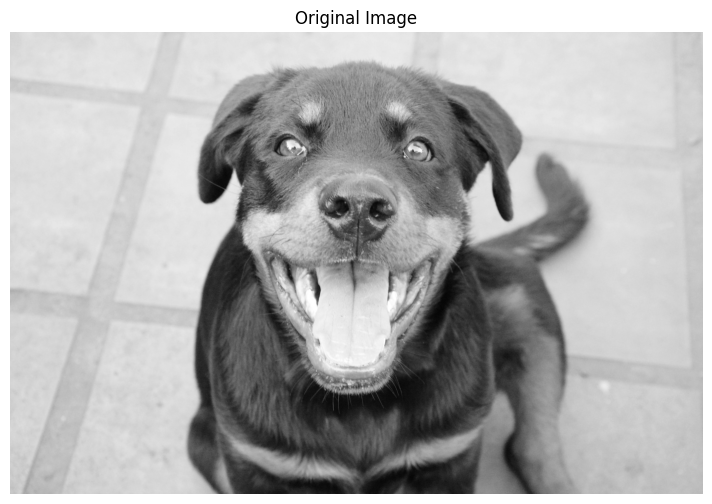

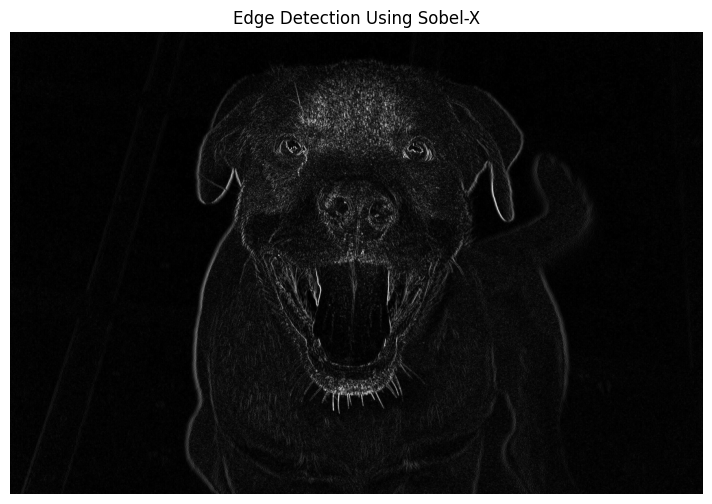

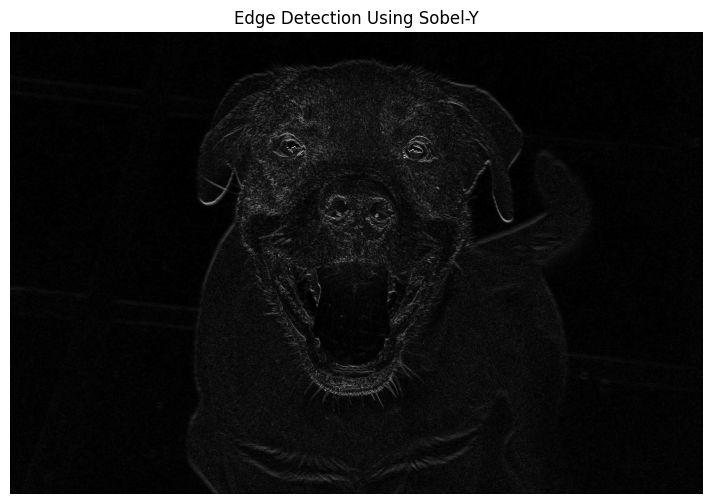

In [5]:
# TASK 1: Implement Edge Detection Using Convolution 

# Import NumPy for creating the Sobel filter matrices
# and OpenCV for loading and processing the image.
import numpy as np
import cv2


# i. Load a grayscale image (you can use any sample image)

# Load the sample image directly in grayscale.
# Grayscale represents each pixel using one intensity value instead
# of separate red, green, and blue values, which makes it suitable
# for detecting changes in intensity with the Sobel filters.
image = cv2.imread("sample_image.jpg", cv2.IMREAD_GRAYSCALE)

# Check that the image was loaded successfully.
if image is None:
    print("Image could not be loaded. Check the file name and location.")
else:
    print("Image loaded successfully!")
    print("Image shape:", image.shape)




# ii. Apply the Sobel filter for edge detection in the x-direction and y-direction

# Define the exact 3x3 Sobel-X filter provided in the question.
# Sobel-X measures changes in pixel intensity from left to right,
# which helps highlight vertical edges in the image.
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# Define the exact 3x3 Sobel-Y filter provided in the question.
# Sobel-Y measures changes in pixel intensity from top to bottom,
# which helps highlight horizontal edges in the image.
sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

# Apply each Sobel filter to the grayscale image using convolution.
# CV_32F keeps both positive and negative edge responses instead
# of discarding information during the convolution.
edges_x = cv2.filter2D(image, cv2.CV_32F, sobel_x)
edges_y = cv2.filter2D(image, cv2.CV_32F, sobel_y)

# Convert the edge responses to absolute 8-bit values (0-255) so the detected edges can be displayed clearly as images.
edges_x = cv2.convertScaleAbs(edges_x)
edges_y = cv2.convertScaleAbs(edges_y)

print("\nSobel-X edge detection completed.")
print("Sobel-Y edge detection completed.")
print("\nSobel-X shape:", edges_x.shape)
print("Sobel-Y shape:", edges_y.shape)




# iii. Display the original image and the filtered images

# Import Matplotlib to display the three images clearly in the notebook.
import matplotlib.pyplot as plt

# Display the original grayscale image.
plt.figure(figsize=(10, 6))
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

# Display the edges detected using the Sobel-X filter.
# Sobel-X mainly highlights vertical edges by detecting changes in pixel intensity from left to right.
plt.figure(figsize=(10, 6))
plt.imshow(edges_x, cmap="gray")
plt.title("Edge Detection Using Sobel-X")
plt.axis("off")
plt.show()

# Display the edges detected using the Sobel-Y filter.
# Sobel-Y mainly highlights horizontal edges by detecting changes in pixel intensity from top to bottom.
plt.figure(figsize=(10, 6))
plt.imshow(edges_y, cmap="gray")
plt.title("Edge Detection Using Sobel-Y")
plt.axis("off")
plt.show()

In [7]:
# TASK 2: Implement Max Pooling and Average Pooling 

# Import TensorFlow for the Max Pooling and Average Pooling operations.
import tensorflow as tf


# i. Create a random 4x4 matrix as an input image

# Create a random 4x4 matrix containing integer values from 1 to 9.
# A fixed seed makes the same random matrix appear each time the code is run,
# making the pooling results reproducible.
np.random.seed(42)
input_matrix = np.random.randint(1, 10, size=(4, 4))

# TensorFlow pooling layers expect input in 4D format: [batch, height, width, channels].
# Therefore, reshape the 4x4 matrix to [1, 4, 4, 1].
input_tensor = tf.reshape(
    tf.cast(input_matrix, tf.float32),
    [1, 4, 4, 1]
)




# ii. Apply a 2x2 Max Pooling operation

# Max Pooling examines each 2x2 region and keeps
# the largest value from that region.
max_pool = tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2)
)

max_pooled = max_pool(input_tensor)




# iii. Apply a 2x2 Average Pooling operation

# Average Pooling examines each 2x2 region and calculates the average of the values in that region.
average_pool = tf.keras.layers.AveragePooling2D(
    pool_size=(2, 2)
)

average_pooled = average_pool(input_tensor)




# iv. Print the original matrix, max-pooled matrix, and average-pooled matrix

print("Original 4x4 Matrix:")
print(input_matrix)

# [0, :, :, 0] removes the extra batch and channel dimensions so that only the resulting 2D pooled matrix is displayed.
print("\nMax-Pooled Matrix:")
print(max_pooled[0, :, :, 0].numpy())

print("\nAverage-Pooled Matrix:")
print(average_pooled[0, :, :, 0].numpy())

Original 4x4 Matrix:
[[7 4 8 5]
 [7 3 7 8]
 [5 4 8 8]
 [3 6 5 2]]

Max-Pooled Matrix:
[[7. 8.]
 [6. 8.]]

Average-Pooled Matrix:
[[5.25 7.  ]
 [4.5  5.75]]


### Observation

In Task 1, a **2000 × 3000 grayscale image** was processed using the provided Sobel-X and Sobel-Y filters. Sobel-X emphasized changes in pixel intensity from left to right, making vertical edges more noticeable, while Sobel-Y emphasized changes from top to bottom, making horizontal edges more noticeable. The filtered images clearly highlighted boundaries and details around the dog’s face, eyes, ears, mouth, body, and surrounding areas. This demonstrated how convolution filters can extract different directional features from an image.

In Task 2, **2×2 Max Pooling and Average Pooling** were applied to a random 4×4 matrix. Both operations reduced the matrix from **4×4 to 2×2**, but summarized each region differently. Max Pooling retained the largest value in each 2×2 region, producing `[[7, 8], [6, 8]]`, while Average Pooling calculated the mean of each region, producing `[[5.25, 7.00], [4.50, 5.75]]`.

Overall, the tasks demonstrated two important CNN operations: **convolution filters extract useful features such as edges, while pooling reduces the size of the data while preserving or summarizing important information.**
